# Campaign for selling personal loans.

##### This case is about a bank (Thera Bank) which has a growing customer base. Majority of these customers are liability customers (depositors) with varying size of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors). A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio with minimal budget.

##### The department wants to build a model that will help them identify the potential customers who have higher probability of purchasing the loan. This will increase the success ratio while at the same time reduce the cost of the campaign.

##### The file Bank.xls contains data on 5000 customers. The data include customer demographic information (age, income, etc.), the customer's relationship with the bank (mortgage, securities account, etc.), and the customer response to the last personal loan campaign (Personal Loan). Among these 5000 customers, only 480 (= 9.6%) accepted the personal loan that was offered to them in the earlier campaign.

## DataSet Description: 
#### ID - Customer ID
#### Age - Customer's age in completed years
#### Experience - Number years of professional experience
#### Income - Annual income of the customer (US Dollars)
#### ZIPCode - Home Address ZIP code.
#### Family - Family size of the customer
#### CCAvg - Avg. spending on credit cards per month (US Dollars)
#### Education - Education Level. 1: Undergrad; 2: Graduate; 3: Advanced/Professional
#### Mortgage - Value of house mortgage if any. (US Dollars)
#### Personal Loan - Did this customer accept the personal loan offered in the last campaign?
#### Securities Account - Does the customer have a securities account with the bank?
#### CD Account - Does the customer have a certificate of deposit (CD) account with the bank?
#### Online - Does the customer use internet banking facilities?
#### CreditCard - Does the customer use a credit card issued by UniversalBank?

## Task 1: Data Loading  (5 Marks)
Perform the following tasks

1. Import the necessary libraries required
2. Read the csv into a dataframe
3. Display the first five rows of your dataframe.
4. Display the datatypes of the columns
5. Display the column names in the dataframe

### 1.1 Importing Libraries

In [31]:
# Import the necessary libraries required

# data manipulation 
import pandas as pd
import numpy as np

# deep learning tools
import tensorflow as tf
import keras_tuner as kt

# ML algorithms
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier, XGBRFClassifier
from sklearn.tree import DecisionTreeClassifier

# feature engineering tools
from scipy.stats import pearsonr
from sklearn.feature_selection import RFECV
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer

# algorithm metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score, f1_score
from sklearn.model_selection import GridSearchCV , StratifiedKFold
from sklearn.pipeline import Pipeline

# visualization tools
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### 1.2 Read dataframe

In [3]:
# Read the csv into a dataframe
personal_loan_df = pd.read_csv('../data/Bank_Personal_Loan_Modelling-1.csv')

pd.set_option('display.max_columns', None)

### 1.3 Display 1st 5 rows

In [4]:
# Display the first five rows of your dataframe.
personal_loan_df.head(5)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


### 1.4 Dtypes of the columns

In [5]:
# Display the datatypes of the columns
personal_loan_df.dtypes

ID                      int64
Age                     int64
Experience              int64
Income                  int64
ZIP Code                int64
Family                  int64
CCAvg                 float64
Education               int64
Mortgage                int64
Personal Loan           int64
Securities Account      int64
CD Account              int64
Online                  int64
CreditCard              int64
dtype: object

### 1.5 Column Names of the df

In [6]:
# Display the column names in the dataframe
print(list(personal_loan_df.columns))

['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']


## Task 2: Data Cleaning (10 Marks)

1. Drop the unnecessary columns in the dataframe(i.e. 'ID'). <b>(2Marks)</b>
2. Check for missing values in the dataframe and display the count in ascending order. Impute the missing values. <b>(2Marks)</b>
3. Check whether there are any duplicate values in the dataframe and if present remove them. <b>(2Marks)</b>
4. Display the total number of records in the dataframe after removing the duplicates. <b>(2Marks)</b>
5. Create a 5 Point summary of the data. <b>(2Marks)</b>

### 2.1 Unnecessary column drops

In [7]:
# Drop the unnecessary columns in the dataframe(i.e. 'ID')
personal_loan_df.drop(columns={"ID"},axis=1, inplace=True)

### 2.2 Handling missing Values

In [8]:
# a function for handling missing values
def missing_Val(df):
    # if df is a dataframe
    if isinstance(df, pd.DataFrame):
        missing_count = df.isna().sum().sum()
    # if df is a series
    elif isinstance(df, pd.Series):
        missing_count = df.isna().sum()
    # if df id neither dataframe or a series
    else:
        print("err! : not a valid data type")
        exit() 

    if missing_count == 0:
        state = False
        print(f"{state}, no missing values present")
    else:
        state = True
        print(f"{state}, {missing_count} - Missing Values")

In [9]:
missing_Val(personal_loan_df)

False, no missing values present


In [10]:
# Check for missing values in the dataframe and display the count in ascending order. Impute the missing values
missing_Val(personal_loan_df)

False, no missing values present


### 2.3 Check for duplicates

In [11]:
personal_loan_df.shape

(5000, 13)

In [12]:
# Check whether there are any duplicate values in the dataframe and if present remove them
print(personal_loan_df.duplicated().sum())

0


### 2.4 Total No.Of records in df

In [13]:
# Display the total number of records in the dataframe after removing the duplicates.
personal_loan_df.drop_duplicates(inplace=True)
print(personal_loan_df.duplicated().sum())

0


In [14]:
personal_loan_df.shape

(5000, 13)

* Since, there were no duplicate found , it's still 5000 records

### 2.5 Five Point Summary of the Data

In [15]:
personal_loan_df.describe()

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [16]:
personal_loan_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   ZIP Code            5000 non-null   int64  
 4   Family              5000 non-null   int64  
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   int64  
 7   Mortgage            5000 non-null   int64  
 8   Personal Loan       5000 non-null   int64  
 9   Securities Account  5000 non-null   int64  
 10  CD Account          5000 non-null   int64  
 11  Online              5000 non-null   int64  
 12  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 546.9 KB


In [17]:
df_col_ls = personal_loan_df.columns.tolist()
df_col_ls

for i in df_col_ls:
    print(f"{i}, Unique Values: \n {personal_loan_df[i].unique()}")

Age, Unique Values: 
 [25 45 39 35 37 53 50 34 65 29 48 59 67 60 38 42 46 55 56 57 44 36 43 40
 30 31 51 32 61 41 28 49 47 62 58 54 33 27 66 24 52 26 64 63 23]
Experience, Unique Values: 
 [ 1 19 15  9  8 13 27 24 10 39  5 23 32 41 30 14 18 21 28 31 11 16 20 35
  6 25  7 12 26 37 17  2 36 29  3 22 -1 34  0 38 40 33  4 -2 42 -3 43]
Income, Unique Values: 
 [ 49  34  11 100  45  29  72  22  81 180 105 114  40 112 130 193  21  25
  63  62  43 152  83 158  48 119  35  41  18  50 121  71 141  80  84  60
 132 104  52 194   8 131 190  44 139  93 188  39 125  32  20 115  69  85
 135  12 133  19  82 109  42  78  51 113 118  64 161  94  15  74  30  38
   9  92  61  73  70 149  98 128  31  58  54 124 163  24  79 134  23  13
 138 171 168  65  10 148 159 169 144 165  59  68  91 172  55 155  53  89
  28  75 170 120  99 111  33 129 122 150 195 110 101 191 140 153 173 174
  90 179 145 200 183 182  88 160 205 164  14 175 103 108 185 204 154 102
 192 202 162 142  95 184 181 143 123 178 198 201 203 189 1

In [18]:
# Create a 5 Point summary of the data

5 Point Summary of the Dataset (Personal Loan)
* This dataset contains 5000 records
* Binary Features => [`Personal Loan`,`Securities Account`,`CD Account`,`Online`,`Credit Card`]  ('0' or '1').
* Numerical and Non-Continous Values => [`Income`,`ZIP Code`,`CCAVG`,`Mortgage`]
* Multi-Categorical Values => [`Age`,`Family`,`Education`]
* Initially there were no Null or Duplicate Values found.

## Task 3: Data Analysis and Visualization (20Marks)

1. Check for correlation of the attributes in the dataframe and plot the heatmap for the same. <b>(4Marks)</b>
2. Plot a pairplot for the attributes. Use "Personal Loan" as hue. <b>(4Marks)</b>
3. From the above visualization identify the attributes that are correlated and drop the unnecessary attribute(column) <b>(4Marks)</b> 
4. Plot a boxplot to understand the distribution of data for the attributes such as "Age", "Income", Family", "CCAvg", "Education", "Mortgage" by taking x axis as "Personal Loan" <b>(4Marks)</b> 
5. Display the unique values of attributes "Family", "Education" and "Personal loan" and plot a bargraph. <b>(4Marks)</b>

CLEAN → `(VISUALIZE)` → FEATURE ENG → (TEMPORARY SCALE → CORRELATION / RFECV) 
→ SPLIT DATA → APPLY SMOTE (train only) → SCALE (fit on train) → FINAL TRAINING 
→ OPTIMIZE → EVALUATE → DEPLOY

### 3.1 Visualization

#### 3.1.1 Correlation and Heatmap

In [19]:
personal_loan_df.corr()

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
Age,1.000000,0.994215,-0.055269,-0.029216,-0.046418,-0.052012,0.041334,-0.012539,-0.007726,-0.000436,0.008043,0.013702,0.007681
Experience,0.994215,1.000000,-0.046574,-0.028626,-0.052563,-0.050077,0.013152,-0.010582,-0.007413,-0.001232,0.010353,0.013898,0.008967
Income,-0.055269,-0.046574,1.000000,-0.016410,-0.157501,0.645984,-0.187524,0.206806,0.502462,-0.002616,0.169738,0.014206,-0.002385
ZIP Code,-0.029216,-0.028626,-0.016410,1.000000,0.011778,-0.004061,-0.017377,0.007383,0.000107,0.004704,0.019972,0.016990,0.007691
Family,-0.046418,-0.052563,-0.157501,0.011778,1.000000,-0.109275,0.064929,-0.020445,0.061367,0.019994,0.014110,0.010354,0.011588
CCAvg,-0.052012,-0.050077,0.645984,-0.004061,-0.109275,1.000000,-0.136124,0.109905,0.366889,0.015086,0.136534,-0.003611,-0.006689
Education,0.041334,0.013152,-0.187524,-0.017377,0.064929,-0.136124,1.000000,-0.033327,0.136722,-0.010812,0.013934,-0.015004,-0.011014
Mortgage,-0.012539,-0.010582,0.206806,0.007383,-0.020445,0.109905,-0.033327,1.000000,0.142095,-0.005411,0.089311,-0.005995,-0.007231
Personal Loan,-0.007726,-0.007413,0.502462,0.000107,0.061367,0.366889,0.136722,0.142095,1.000000,0.021954,0.316355,0.006278,0.002802
Securities Account,-0.000436,-0.001232,-0.002616,0.004704,0.019994,0.015086,-0.010812,-0.005411,0.021954,1.000000,0.317034,0.012627,-0.015028


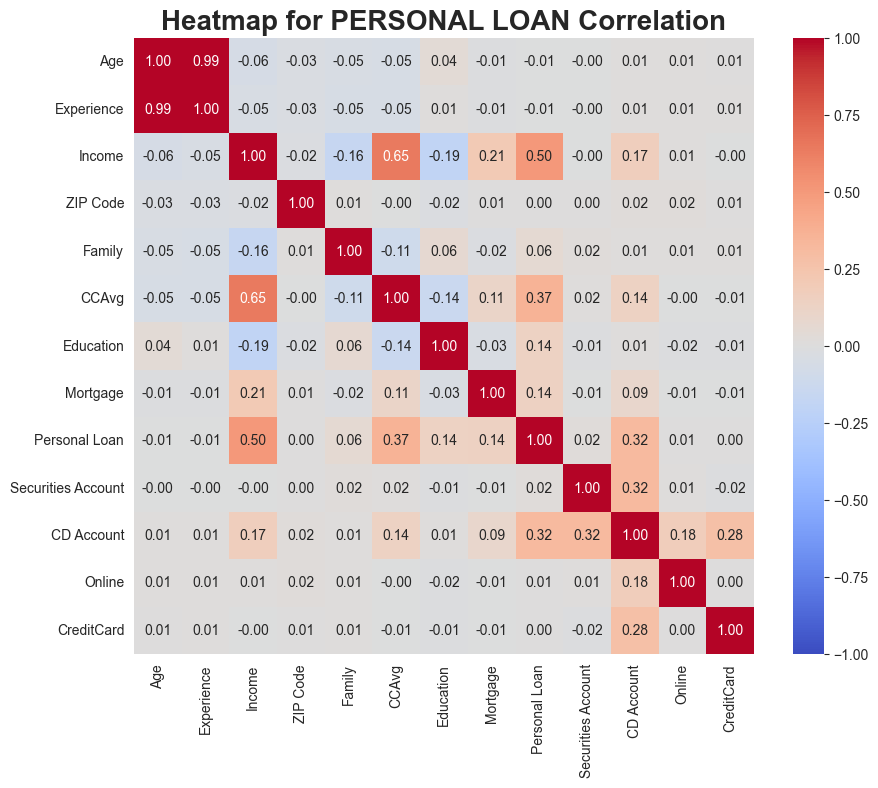

<Figure size 640x480 with 0 Axes>

In [20]:
# Check for correlation of the attributes in the dataframe and plot the heatmap for the same.

plt.figure(figsize = (10,8))

sns.heatmap(personal_loan_df.corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm" , fmt=".2f")

plt.title("Heatmap for PERSONAL LOAN Correlation",fontweight="bold", fontsize=20)

plt.show()

plt.savefig("../visualization/heatmap.png")

#### 3.1.2 Pairplot 

<Figure size 1500x2000 with 0 Axes>

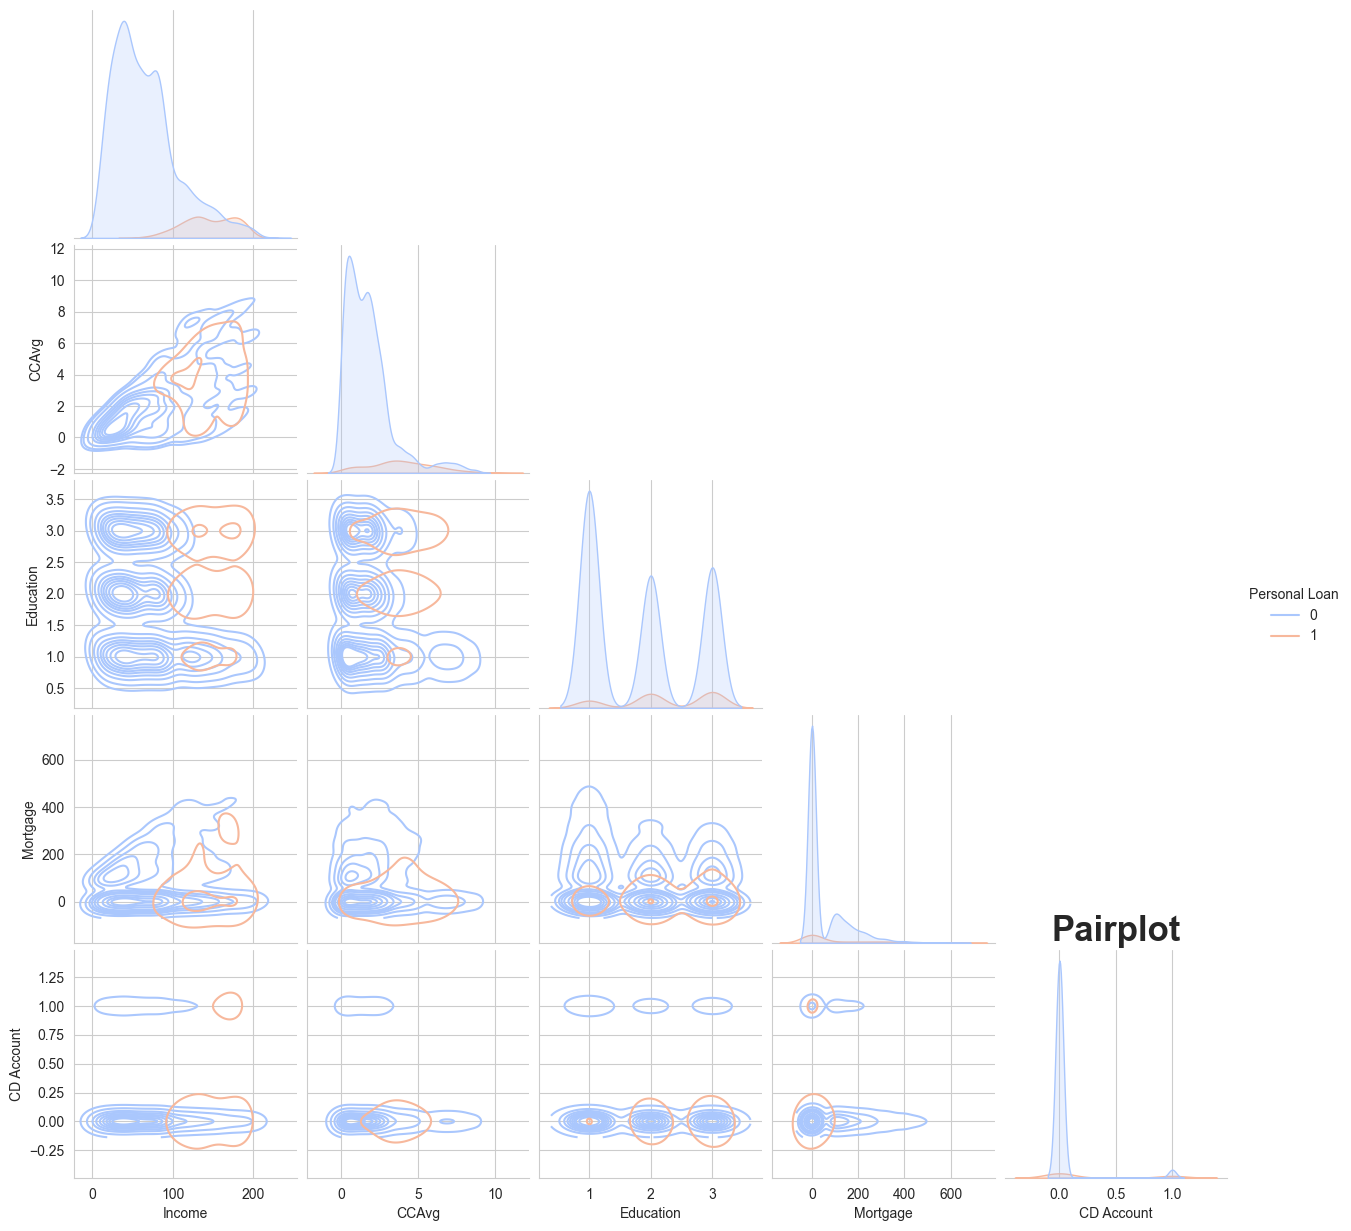

<Figure size 640x480 with 0 Axes>

In [21]:
# Plot a pairplot for the attributes. Use "Personal Loan" as hue. 

plt.figure(figsize=(15,20))

sns.pairplot(
    data = personal_loan_df, hue = "Personal Loan", palette = "coolwarm", kind = "kde",
    x_vars=["Income","CCAvg","Education","Mortgage","CD Account"],
    y_vars=["Income","CCAvg","Education","Mortgage","CD Account"], corner = True
)

plt.title("Pairplot", fontweight="bold", fontsize=25)

plt.show()

plt.savefig("../visualization/pairplot.png")

#### 3.1.3 Feature Identification

In [22]:
# From the above visualization identify the attributes that are correlated and drop the unnecessary attribute(column)
new_df = personal_loan_df.drop(columns={"Age","Experience","ZIP Code","Online","CreditCard"},axis=1)
new_df.head(5)

,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account
0,49,4,1.6,1,0,0,1,0
1,34,3,1.5,1,0,0,1,0
2,11,1,1.0,1,0,0,0,0
3,100,1,2.7,2,0,0,0,0
4,45,4,1.0,2,0,0,0,0


#### 3.1.4 Boxplot

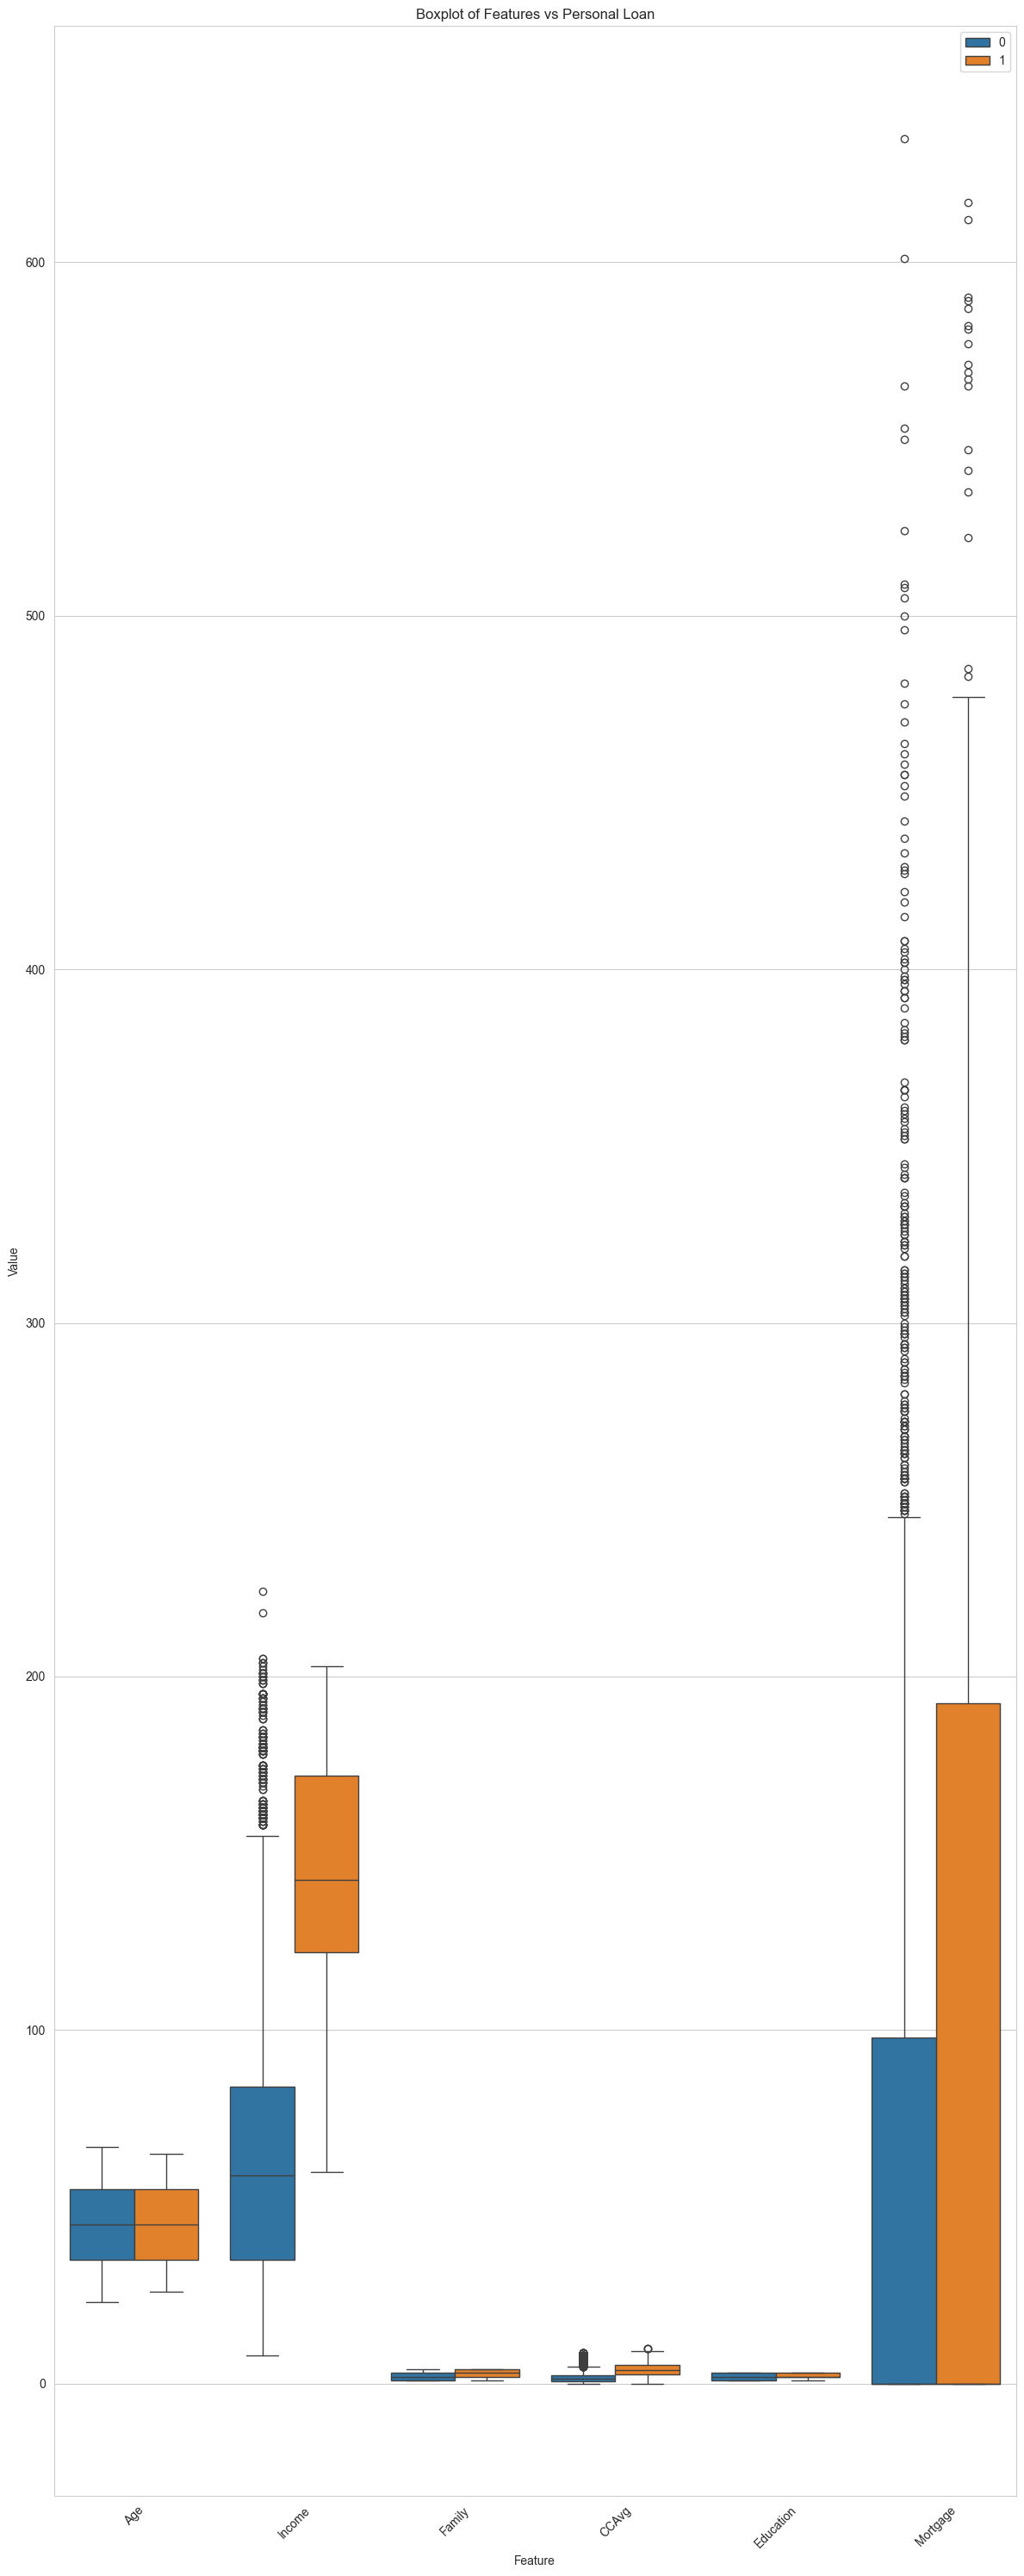

<Figure size 640x480 with 0 Axes>

In [23]:
# Plot a boxplot to understand the distribution of data for the attributes such as "Age", "Income", "Family", "CCAvg", "Education", "Mortgage" by taking x axis as "Personal Loan"

# Select relevant columns
cols = ["Age", "Income", "Family", "CCAvg", "Education", "Mortgage", "Personal Loan"]
df_melted = personal_loan_df[cols].melt(id_vars="Personal Loan", 
                                         var_name="Feature", value_name="Value")

# Create the boxplot
plt.figure(figsize=(12, 30))

sns.boxplot(data=df_melted, x="Feature", y="Value", hue="Personal Loan")

plt.title("Boxplot of Features vs Personal Loan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

plt.savefig("../visualization/boxplots.png")

#### 3.1.5 Bargraph

In [24]:
# Display the unique values of attributes "Family", "Education" and "Personal loan" and plot a bargraph.
ls = ["Family","Education","Personal Loan"]
for i in ls:
    print(f"Unique Values of {i},\n{personal_loan_df[i].unique()}")

Unique Values of Family,
[4 3 1 2]
Unique Values of Education,
[1 2 3]
Unique Values of Personal Loan,
[0 1]


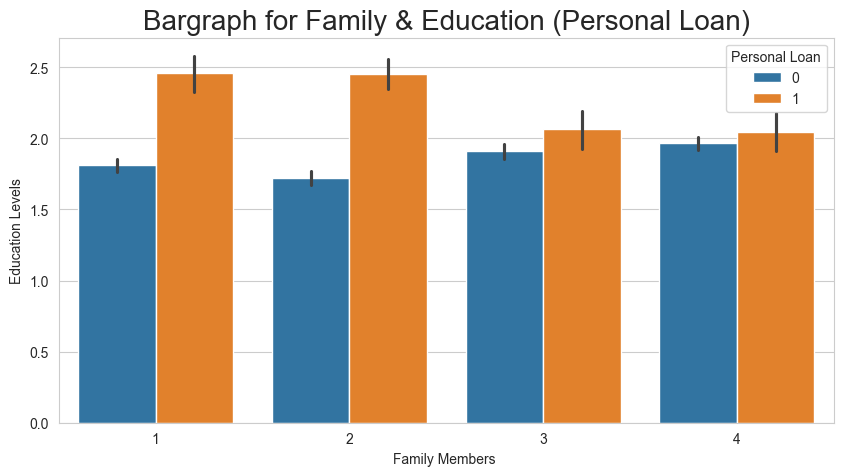

<Figure size 640x480 with 0 Axes>

In [25]:
# bargraph plotting

plt.figure(figsize=(10,5))

sns.barplot(data = personal_loan_df, x="Family",y="Education",hue="Personal Loan")

plt.title("Bargraph for Family & Education (Personal Loan)",fontsize=20)
plt.xlabel("Family Members ", fontsize=10)
plt.ylabel("Education Levels", fontsize=10)
plt.show()

plt.savefig("../visualization/Family Education.png")

In [26]:
personal_loan_df.to_csv("../data/cleaned_data.csv")

### 3.2 Data Analysis

#### 3.2.1 Pearson Correlation

In [27]:
# Finding the best features which has the best correlation to "Personal Loan"
personal_loan_X = personal_loan_df.drop(columns={"Personal Loan"},axis=1)
personal_loan_Y = personal_loan_df["Personal Loan"]

# initializing the variable dictionary
PL_corr = {}
features = list(personal_loan_X.columns)
# print(features)
# inserting elements into the dict
for i in features:
    corr , pval = pearsonr(personal_loan_X[i], personal_loan_Y)
    p_str = str()
    if pval <= 0.0001:
        p_str="strong"
    elif pval<= 0.05:
        p_str="moderate"
    elif pval<=0.1:
        p_str="weak"
    else:
        p_str="No Corr"
    PL_corr[i] = {"corr":corr, "pval":pval, "state":p_str}


PL_corr_df = pd.DataFrame.from_dict(PL_corr)

PL_corr_df = PL_corr_df.transpose()

In [28]:
PL_corr_df.head(6)

,corr,pval,state
Age,-0.007726,0.584959,No Corr
Experience,-0.007413,0.600236,No Corr
Income,0.502462,0.0,strong
ZIP Code,0.000107,0.993944,No Corr
Family,0.061367,0.000014,strong
CCAvg,0.366889,0.0,strong


In [29]:
PL_corr_df.tail(6)

,corr,pval,state
Education,0.136722,0.0,strong
Mortgage,0.142095,0.0,strong
Securities Account,0.021954,0.120621,No Corr
CD Account,0.316355,0.0,strong
Online,0.006278,0.657186,No Corr
CreditCard,0.002802,0.843008,No Corr


* While using `pearsonr` we were able to see only 6 columns with strong correlation with the Personal Loan 
* features Include : [ `Income`, `Family`, `CCAvg`,`Education`,`Mortgage`,`CD Account`]

#### 3.2.2 RFECV Feature Extraction

RFECV - Recursive Feature Elimination with Cross Validation
since RFECV needs a model to perform its duty to find best features 
we will move with 4 basic models:-
* Logistic Regression
* KNN (also not supported)
* SVC (NOt Supported with RFECV)
* Random Forest
* Decision Tree
* Gradient Boosting

In [32]:
# initializing the Models
models = {
    "logR": LogisticRegression(),
    # "SVC" : SVC(kernel='sigmoid', degree=3),
    "RandomForest": RandomForestClassifier(criterion="entropy"),
    # "KNN" : KNeighborsClassifier(n_neighbors=5, algorithm="brute"),
    "DecisionTree": DecisionTreeClassifier(splitter="best"),
    "GradientBoosting" : GradientBoostingClassifier()
}

# intiating cross validation
strat_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=3)

# best features
chosen_features_per_model = {}

# looping through every model
for name , model in models.items():
    # initiating rfecv
    rfecv_model = RFECV(estimator=model , cv=strat_cv, scoring='accuracy', n_jobs=-1)
    
    # fitting the data into the model
    rfecv_model.fit(personal_loan_X , personal_loan_Y)
    
    # choosing the best features
    chosen_features = personal_loan_X.columns[rfecv_model.support_].tolist()
    # feature assignment
    chosen_features_per_model[name] = chosen_features
# 
# # converting the feature dictionary to dataframe
# chosen_features_per_model_df = pd.DataFrame.from_dict(chosen_features_per_model)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

In [33]:
tuple(chosen_features_per_model.values())

(['Family',
  'CCAvg',
  'Education',
  'Securities Account',
  'CD Account',
  'Online',
  'CreditCard'],
 ['Age', 'Income', 'Family', 'CCAvg', 'Education', 'CD Account'],
 ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education', 'CD Account'],
 ['Income', 'Family', 'CCAvg', 'Education'])

#### 3.2.3 Extracted Features

From the list provided we can conclude that the features
* Family
* CCAvg
* Education
* Income
* CD Account

These are the essential features for the model. However, we will also include `Mortgage` feature considering the Correlation for the Heatmap as well

In [34]:
# so our new dataset are :-
new_df = personal_loan_df[["Family", "CCAvg", "Education", "Income", "CD Account", "Mortgage", "Personal Loan"]].copy()


#### 3.2.4 Validating the Dataset

In [35]:
# checking for missing values
missing_Val(new_df)

False, no missing values present


In [36]:
# checking for duplicate values
new_df.duplicated().sum()

469

In [37]:
print("Shape of the Data : ",new_df.shape)
print("Number of People who took Personal Loan =>", new_df[new_df["Personal Loan"]==1]["Personal Loan"].value_counts())

Shape of the Data :  (5000, 7)
Number of People who took Personal Loan => 1    480
Name: Personal Loan, dtype: int64


In [38]:
# dropping the duplicated values from the new_data
new_df.drop_duplicates(inplace=True)

In [39]:
print("Shape of the Data : ",new_df.shape)
print("Number of People who took Personal Loan =>", new_df[new_df["Personal Loan"]==1]["Personal Loan"].value_counts())

Shape of the Data :  (4531, 7)
Number of People who took Personal Loan => 1    480
Name: Personal Loan, dtype: int64


In [40]:
new_df.to_csv("../data/final_features_data_df.csv")

## Task 4: Modelling (25Marks)

1. Split data into X and Y. <b>(1Marks)</b>
2. Split the data into training and test set in the ratio of 70:30 respectively <b>(2Marks)</b>
3. Train a Supervised Learning Classification base model using KNN classifier, Naive Bayes and Logistic Regression. Print the train and test accuracy for the same <b>(12Marks)</b>
4. Print the confusion matrix for all the above models <b>(5Marks)</b>
5. Give your reasoning on which is the best model in this case and why it performs better <b>(5Marks)</b>

### 4.1 Split X and y

In [41]:
# Split data into X and Y.
X = new_df.iloc[:,:6]
y = new_df["Personal Loan"]

### 4.2 Split Train & Test set

In [42]:
# Split the data into training and test set in the ratio of 70:30 respectively 
# stratify means it will produce equal distribution on the test set as it did on train set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

# checkinng the train and test set shape and size
print(f"X_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_test shape : {y_test.shape}")

X_train shape : (3171, 6)
y_train shape : (3171,)
X_test shape : (1360, 6)
y_test shape : (1360,)


#### 4.2.1 Saving the Train and Test Set

In [43]:
# Combine X_train (features) and y_train (target) into one DataFrame
train_set2 = pd.concat([pd.DataFrame(X_train), pd.DataFrame(y_train)], axis=1)
test_set = pd.concat([pd.DataFrame(X_test) , pd.DataFrame(y_test)], axis=1)

# Optional: name the target column properly
train_set2.columns = list(X_train.columns) + ["Personal Loan"]
test_set.columns = list(X_test.columns) + ["Personal Loan"]

# Save to CSV
train_set2.to_csv('../data/biased cleaned data/biased_train_set.csv', index=False)
test_set.to_csv('../data/biased cleaned data/biased_test_set.csv', index=False)


#### 4.2.2 Data Transformation

 * `ColumnTransformation` : Applies different transformations to different columns in a single step.

In [44]:
# Transforming the data train set
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape : {y_train.shape}")

numerical_cols = ["CCAvg", "Income", "Mortgage"]
categorica_cols = ["Family", "Education", "CD Account"]

# transforming categorical and numerical column with ColumnTransformer, StandardScaler and OneHotEncoding
preprocessing = ColumnTransformer(
    transformers=[
        ('numericals', StandardScaler(), numerical_cols),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorica_cols)
    ]
)

# fit and transform the trainset and just transform the test set
X_train_processed = preprocessing.fit_transform(X_train)
X_test_processed = preprocessing.transform(X_test)



X_train shape : (3171, 6)
X_test shape : (3171,)


In [74]:
X_train_processed.shape

(3171, 12)

#### 4.2.3 SMOTE - Dealing with Minority Set

In [45]:
# Using the Smote() for resolving the imbalance learning from the train set
smt = SMOTE(random_state=333)

# fitting the smote() - Synthetic Minority Oversampling Technique
X_train_resampled , y_train_resampled = smt.fit_resample(X_train_processed, y_train)

# shape and size of the 
print(f"Resampled X_train Shape {X_train_resampled.shape}")
print(f"Resample y_train shape {y_train_resampled.shape}")




Resampled X_train Shape (5670, 12)
Resample y_train shape (5670,)


In [46]:
# number of yes and no
print(f"The number of personal loans (yes) {(y_train_resampled==1).sum()} ")
# number of yes and no
print(f"The number of personal loans (no) {(y_train_resampled==0).sum()} ")

The number of personal loans (yes) 2835 
The number of personal loans (no) 2835 


* Saving the unbiased trainset 


In [47]:
X_train.shape

(3171, 6)

In [48]:
X_train_resampled.shape

(5670, 12)

#### 4.2.4 Saving Unbiased trainset

In [49]:
# gettin features name 
feature_names = preprocessing.get_feature_names_out()

# Combine features + target
X_df = pd.DataFrame(X_train_resampled, columns=feature_names)
y_df = pd.DataFrame(y_train_resampled, columns=["target"])

# Combine into one DataFrame
train_set = pd.concat([X_df, y_df], axis=1)

# Save to CSV
train_set.to_csv("../data/unbiased dataset/unbiased_train_set.csv", index=False)
print("Saved unbiased train set to CSV!")

Saved unbiased train set to CSV!


### 4.3 Model Training (ML)

#### 4.3.1 Models Description (`ML Algo's`)

Machine learning models that are being used are :- 
1. Logistic Regression 
    - a type of regression model that predicts probability
    - Uses `sigmoid` function 
2. SVC
    - Support Vector Classifier uses `Hyperplane` making the boundaries between 2 or more classification.
3. Random Forest Classifiers
    - Decision Trees are the building blocks for RFC and better performer than a single decision tree .
    - focuses on reducing variance by creating diverse, independent models and combining them. 
4. KNearestNeighbour [KNN]
    - Instance Based classifier , chooses neighbours based on the `No.Of neighbours` that you want to choose.
5. RadiusNeighborsClassifier
    - Instance Based Classifier , chooses its neighours based on the `distance(radius)` of the current point and what all neighbours `within` the `radius` are considered `neighbours`.

6. AdaBoostClassifier - Adaptive Boosting Classifier
    - `combines` multiple weak learners(shallow decision trees) `sequentially` from `decision stumps`.
7. BaggingClassifier
    - Trains `multiple decision trees` on different `bootstrapped samples` and `aggregates` their decision.
8. RidgeClassifier 
    - `Minimizes` squared `loss` with l2 regularization, works better for small datasets.

9. Gradient Boosting Classifier
    - each new model tries to correct the `residual errors` of the combined previous models by `minimizing` a `loss function` using `gradient descent`. works best with medium-sized data.
    - focuses on reducing bias by correcting mistakes in sequential trees. 

10. CatBoostClassifier - developed by Yandex
    - Categorical feature handling, and symmetric tree handling
11. LGBMClassifier - Light Gradient Boosting Classifier by `Microsoft`
    - uses `tree-based` learning algorithm, utilizes `leaf-wise growth`, finds more complex patterns.
12. XGBClassifier - eXtreme Gradient Boosting Classifier
    - boosts weak learner and corrects previous one's (trees) mistake.
13. XGBRFClassifier - eXtreme Gradient Boosting Random Forest Classifier
    - trained with Random Forest and uses framework of gradient boosting.

#### 4.3.2 Model Initialization

In [68]:
# Train a Supervised Learning Classification base model using KNN classifier, Naive Bayes and Logistic Regression. Print the train and test accuracy for the same

# some random parameters for each ML models
classification_ML_models = {
    "Logistic_Regression" : LogisticRegression(penalty="l2", solver="newton-cholesky"),
    "Support_Vector_Classifiers": SVC(probability=True, kernel = "sigmoid", degree=7),
    "Random_Forest_Classifiers" : RandomForestClassifier(max_depth=100 , n_estimators=500, ),
    "K-Nearest_Neighbor": KNeighborsClassifier( n_neighbors=5, algorithm="auto", metric="minkowski" ),
    "Radius_Neighbors_Classifiers": RadiusNeighborsClassifier(radius=2.50),
    "Adaptive Boosting Classifiers" : AdaBoostClassifier(n_estimators=100),
    "Bagging Classifiers" : BaggingClassifier( n_estimators=150, max_samples=6),
    # "RidgeClassifer" : RidgeClassifier(),
    "Gradient_Boosting_Classifiers" : GradientBoostingClassifier( n_estimators=500, max_depth=6, subsample=0.8),
    "Cat_Boost_Classifier":CatBoostClassifier( iterations = 750, depth = 15, grow_policy = 'Depthwise' ),
    "Light_Gradient_Boosting_Machine_Classifiers":LGBMClassifier( n_estimators= 250, num_leaves=15, max_depth = 50 ),
    "eXtreme_Gradient_Boosting_Classifier": XGBClassifier( n_estimators= 750, max_depth = 10, subsample=0.9 ),
    "eXtreme_Gradient_Boosting_Random_Forest_Classifiers" : XGBRFClassifier(colsample_bynode=1.0,  num_parallel_tree=150, max_depth=8)
}

#### 4.3.3 Model Choosing

In [69]:
# a new variable for storing the model accuracy for their train and test set 

def ML_model_results(models_ls):
    # initializing an empty list 
    model_result = []
    
    
    # for loop for training each model with metrics
    for model_name , model in models_ls.items():
        # Fit the model
        model_fit = model.fit(X_train_resampled, y_train_resampled)
        
        # Score using built-in model score method (usually returns accuracy for classifiers)
        model_train_score = model_fit.score(X_train_resampled, y_train_resampled)
        model_test_score = model_fit.score(X_test_processed, y_test)
        
        # Predictions
        y_train_pred = model_fit.predict(X_train_resampled)
        y_test_pred = model_fit.predict(X_test_processed)
        
        # For metrics that require probabilities (e.g., ROC-AUC)
        y_train_proba = model_fit.predict_proba(X_train_resampled)[:, 1]
        y_test_proba = model_fit.predict_proba(X_test_processed)[:, 1]
        
        # Accuracy
        model_train_accuracy = accuracy_score(y_train_resampled, y_train_pred)
        model_test_accuracy = accuracy_score(y_test, y_test_pred)
        
        # F1 Score
        model_f1_train = f1_score(y_train_resampled, y_train_pred)
        model_f1_test = f1_score(y_test, y_test_pred)
        
        # ROC AUC Score
        model_roc_auc_train = roc_auc_score(y_train_resampled, y_train_proba)
        model_roc_auc_test = roc_auc_score(y_test, y_test_proba)
        
        # ROC Curve (returns fpr, tpr, thresholds — used for plotting)
        fpr_train, tpr_train, thresholds_train = roc_curve(y_train_resampled, y_train_proba)
        fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_proba)
        
        model_result.append({
            "Model_name": model_name,
            "train_scores" : model_train_score,
            "test_score" : model_test_score,
            "accuracy_train" : model_train_accuracy,
            "accuracy_test" : model_test_accuracy,
            "F1_score_train" : model_f1_train,
            "F1_score_test" : model_f1_test,
            "ROC_AUC_train" : model_roc_auc_train,
            "ROC_AUC_test" : model_roc_auc_test
        })
        
    return model_result


In [70]:
# Sorting through all the mentioned models to see which one is better 
model_selection_df = pd.DataFrame(ML_model_results(classification_ML_models))


Learning rate set to 0.028137
0:	learn: 0.6318446	total: 176ms	remaining: 2m 11s
1:	learn: 0.5784318	total: 284ms	remaining: 1m 46s
2:	learn: 0.5258232	total: 403ms	remaining: 1m 40s
3:	learn: 0.4805887	total: 524ms	remaining: 1m 37s
4:	learn: 0.4416829	total: 644ms	remaining: 1m 35s
5:	learn: 0.4021038	total: 747ms	remaining: 1m 32s
6:	learn: 0.3679439	total: 864ms	remaining: 1m 31s
7:	learn: 0.3348769	total: 983ms	remaining: 1m 31s
8:	learn: 0.3062052	total: 1.11s	remaining: 1m 31s
9:	learn: 0.2806323	total: 1.23s	remaining: 1m 30s
10:	learn: 0.2591789	total: 1.34s	remaining: 1m 29s
11:	learn: 0.2396272	total: 1.48s	remaining: 1m 30s
12:	learn: 0.2217939	total: 1.6s	remaining: 1m 30s
13:	learn: 0.2066737	total: 1.74s	remaining: 1m 31s
14:	learn: 0.1921612	total: 1.85s	remaining: 1m 30s
15:	learn: 0.1799204	total: 1.99s	remaining: 1m 31s
16:	learn: 0.1674070	total: 2.11s	remaining: 1m 31s
17:	learn: 0.1560105	total: 2.23s	remaining: 1m 30s
18:	learn: 0.1457901	total: 2.36s	remaining: 

#### 4.3.4 Model Selection df

In [71]:
model_selection_df.head(6)

,Model_name,train_scores,test_score,accuracy_train,accuracy_test,F1_score_train,F1_score_test,ROC_AUC_train,ROC_AUC_test
0,Logistic_Regression,0.916578,0.908824,0.916578,0.908824,0.917061,0.670213,0.968427,0.958676
1,Support_Vector_Classifiers,0.779012,0.769853,0.779012,0.769853,0.779285,0.394584,0.859967,0.859124
2,Random_Forest_Classifiers,1.000000,0.988235,1.000000,0.988235,1.000000,0.945205,1.000000,0.997927
3,K-Nearest_Neighbor,0.989242,0.966912,0.989242,0.966912,0.989319,0.858044,0.999728,0.979629
4,Radius_Neighbors_Classifiers,0.883774,0.870588,0.883774,0.870588,0.886124,0.582938,0.951304,0.947260
5,Adaptive Boosting Classifiers,0.959612,0.932353,0.959612,0.932353,0.960305,0.735632,0.994243,0.978050


In [72]:
model_selection_df.tail(6)

,Model_name,train_scores,test_score,accuracy_train,accuracy_test,F1_score_train,F1_score_test,ROC_AUC_train,ROC_AUC_test
6,Bagging Classifiers,0.902998,0.852941,0.902998,0.852941,0.908425,0.570815,0.950678,0.944547
7,Gradient_Boosting_Classifiers,1.000000,0.988971,1.000000,0.988971,1.000000,0.947735,1.000000,0.998201
8,Cat_Boost_Classifier,1.000000,0.990441,1.000000,0.990441,1.000000,0.955326,1.000000,0.997973
9,Light_Gradient_Boosting_Machine_Classifiers,1.000000,0.987500,1.000000,0.987500,1.000000,0.941176,1.000000,0.997733
10,eXtreme_Gradient_Boosting_Classifier,0.999824,0.987500,0.999824,0.987500,0.999824,0.941980,1.000000,0.997921
11,eXtreme_Gradient_Boosting_Random_Forest_Classi...,0.994004,0.977206,0.994004,0.977206,0.994029,0.899676,0.999840,0.997621


In [54]:
model_selection_df.to_excel("../models/ML_model_select.xlsx",sheet_name="ML_model_selection")

From the above dataframe we can see that models like :
* Random Forest Classifer
* Gradient Boost
* Cat Boost Classifier
* LightGBM
* XGBoost
* XGBRF Classifier

Are having the least differences between the train and test metrics[F1_scores]

In [84]:
# function for evaluating the testing accuracies with the given model
def ml_model_test_eval(ml_model):    
    """
    Evaluates a trained GridSearchCV model on the test data and plots key performance metrics.
    
    Parameters:
    - grid_model: trained GridSearchCV model
    - X_test: test feature set
    - y_test: true test labels
    """
    # Extract the best estimator from GridSearchCV
    best_model = ml_model.best_estimator_
    
    # Predict class labels
    y_pred = ml_model.predict(X_test_processed)
    
    # Check if predict_proba is available
    if hasattr(ml_model, "predict_proba"):
        y_proba = ml_model.predict_proba(X_test_processed)[:, 1]
    elif hasattr(ml_model, "decision_function"):
        # Some models use decision_function instead
        decision_scores = ml_model.decision_function(X_test_processed)
        y_proba = (decision_scores - decision_scores.min()) / (decision_scores.max() - decision_scores.min())  # min-max scaling
    else:
        print("This model does not support probability or decision scores. ROC AUC will not be computed.")
        y_proba = None

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else "N/A"
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    # Display text results
    print("Best Parameters:\n", ml_model.best_params_)
    print("\nClassification Report:\n", report)
    print("Accuracy:", round(acc, 4))
    print("F1 Score:", round(f1, 4))
    print("ROC AUC Score:", round(roc_auc, 4) if roc_auc != "N/A" else "N/A")

    # Plotting
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axs[0])
    axs[0].set_title('Confusion Matrix')
    axs[0].set_xlabel('Predicted')
    axs[0].set_ylabel('Actual')

    # ROC Curve
    if y_proba is not None:
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)
        axs[1].plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
        axs[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axs[1].set_title('ROC Curve')
        axs[1].set_xlabel('False Positive Rate')
        axs[1].set_ylabel('True Positive Rate')
        axs[1].legend(loc='lower right')
        
        # Threshold plot
        # Align shapes properly
        tpr_plot = tpr[:-1] if len(tpr) > len(thresholds) else tpr
        fpr_plot = fpr[:-1] if len(fpr) > len(thresholds) else fpr
        
        axs[2].plot(thresholds, tpr_plot, label='TPR', color='green')
        axs[2].plot(thresholds, 1 - fpr_plot, label='1 - FPR', color='red')
        axs[2].set_title('Threshold vs TPR & 1 - FPR')
        axs[2].set_xlabel('Threshold')
        axs[2].set_ylabel('Rate')
        axs[2].legend()
    else:
        axs[1].axis('off')
        axs[2].axis('off')

    plt.tight_layout()
    plt.show()

##### 4.3.4.1 Random Forest Classifier

In [78]:
# Random Forest Classifier
random_forest_parameters = {
    'n_estimators': [700, 500, 450],                 
    'criterion': ['gini'],                           # gini is fast and usually solid
    'max_depth': [None, 10, 30],                     # cut down to None (full), shallow, mid-depth
    'min_samples_split': [4, 8],                    # reduce
    'min_samples_leaf': [2, 5],                      # reduce
    'min_impurity_decrease': [0.01],                 # stick with one reasonable value
    'max_features': ['sqrt'],                        # commonly best; log2 often close
    'max_leaf_nodes': [50, 100],                     # reduced options
    'bootstrap': [True],                             # Bootstrap=True is standard
    'ccp_alpha': [0.005],                            # One value to regularize
    'max_samples': [0.7]                             # Reasonable subsampling
}

In [79]:
# initializing the random forest gridsearchCV
rf_grid = GridSearchCV(estimator=RandomForestClassifier(), param_grid=random_forest_parameters,
                       cv=4, n_jobs=-1 , scoring="f1_macro", verbose=10)

# fitting the model 
rf_grid.fit(X_train_resampled, y_train_resampled)

# saving the results into df
random_forest_cv_result = pd.DataFrame.from_dict(rf_grid.cv_results_)

# random forest best parameters
rf_best_params = rf_grid.best_params_

# saving the df as a csv for further analysis if needed
random_forest_cv_result.to_csv("../models/ML_trials/random_forest_models/random_forest_cv_results.csv")

Fitting 4 folds for each of 72 candidates, totalling 288 fits


In [87]:
# results 
random_forest_cv_result[random_forest_cv_result['rank_test_score']==1]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_bootstrap,param_ccp_alpha,param_criterion,param_max_depth,param_max_features,param_max_leaf_nodes,param_max_samples,param_min_impurity_decrease,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
55,2.512996,0.057847,0.160502,0.011587,True,0.005,gini,30,sqrt,50,0.7,0.01,5,4,500,"{'bootstrap': True, 'ccp_alpha': 0.005, 'crite...",0.952044,0.964738,0.966829,0.972472,0.964021,0.007471,1


In [80]:
# the best results for random forest 
rf_best_params.values()

dict_values([True, 0.005, 'gini', 30, 'sqrt', 50, 0.7, 0.01, 5, 4, 500])

Best Parameters:
 {'bootstrap': True, 'ccp_alpha': 0.005, 'criterion': 'gini', 'max_depth': 30, 'max_features': 'sqrt', 'max_leaf_nodes': 50, 'max_samples': 0.7, 'min_impurity_decrease': 0.01, 'min_samples_leaf': 5, 'min_samples_split': 4, 'n_estimators': 500}

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.95      0.97      1216
           1       0.69      0.95      0.80       144

    accuracy                           0.95      1360
   macro avg       0.84      0.95      0.89      1360
weighted avg       0.96      0.95      0.95      1360

Accuracy: 0.95
F1 Score: 0.8012
ROC AUC Score: 0.9845


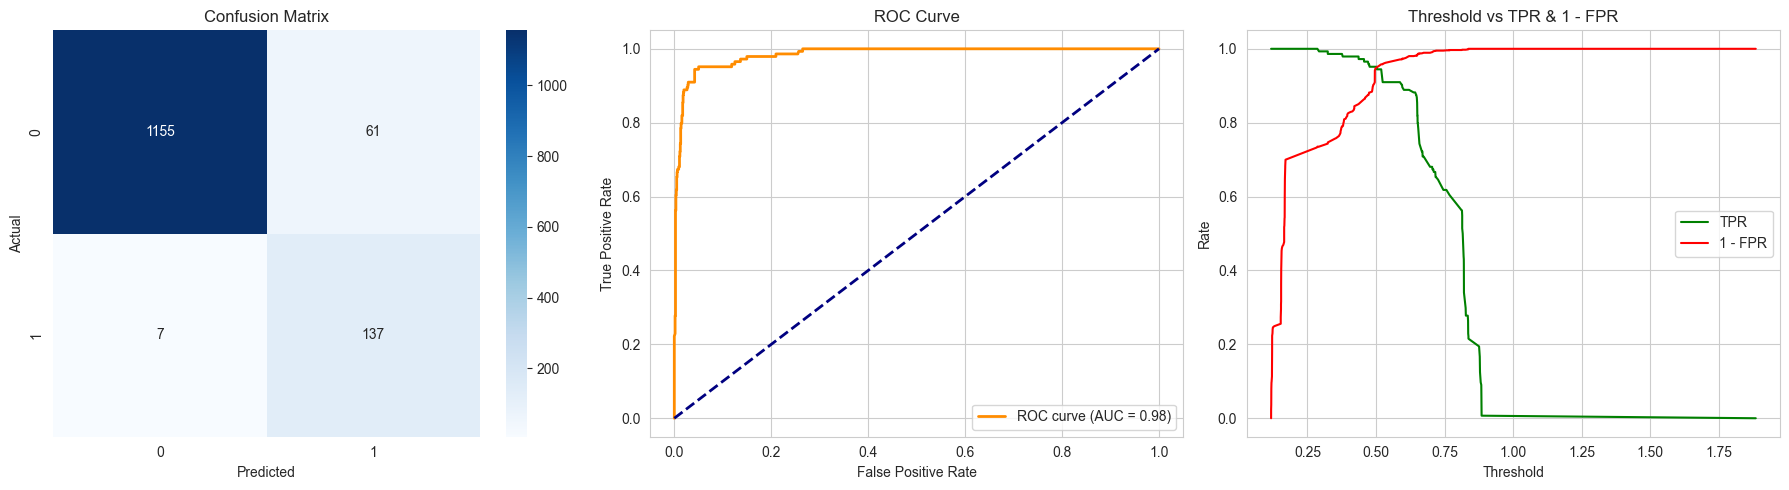

In [85]:
# comparing the results
ml_model_test_eval(rf_grid)

##### 4.2.4.2 Gradient Boosting Classifier

In [ ]:
# passing all the parameters for the gradient boosting classifiers


In [ ]:
# Print the confusion matrix for all the above models

### 4.4 Model Training (NN)

In [ ]:
# NN

## Task 5 : Which Model? 

In [ ]:
# Give your reasoning on which is the best model in this case and why it performs better